# 🇲🇦 Moroccan License Plate Character Detection
## YOLOv8 Training Notebook

**Plate format:** `[1-5 digits]` | `[1 Latin letter]` | `[1-2 digits]`

Example: `66932 | A | 1`

---

## 1 · Install dependencies

In [1]:
!pip install ultralytics opencv-python matplotlib pyyaml --quiet

import ultralytics
ultralytics.checks()

Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152MiB)
Setup complete ✅ (12 CPUs, 167.0 GB RAM, 57.2/368.0 GB disk)


## 2 · Imports & paths

In [2]:
from pathlib import Path

DATASET_ROOT  = Path('/teamspace/studios/this_studio/dataset')

# ── Correct paths matching YOUR actual structure ───────────────────
TRAIN_IMG_DIR = DATASET_ROOT / 'train' / 'images'
TRAIN_LBL_DIR = DATASET_ROOT / 'train' / 'labels'
TEST_IMG_DIR  = DATASET_ROOT / 'test'  / 'images'
TEST_LBL_DIR  = DATASET_ROOT / 'test'  / 'labels'
DATA_YAML     = DATASET_ROOT / 'data.yaml'

print('✅ Dataset root  :', DATASET_ROOT.resolve())
print('   Train images  :', len(list(TRAIN_IMG_DIR.glob('*.*'))))
print('   Train labels  :', len(list(TRAIN_LBL_DIR.glob('*.txt'))))
print('   Test  images  :', len(list(TEST_IMG_DIR.glob('*.*'))))
print('   data.yaml     :', DATA_YAML.exists())

✅ Dataset root  : /teamspace/studios/this_studio/dataset
   Train images  : 1487
   Train labels  : 1487
   Test  images  : 212
   data.yaml     : True


## 3 · Load class names from data.yaml

In [3]:
!pip install pyyaml

In [12]:
import yaml
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg['names']          # dict  {0: '0', 1: '1', ..., 36: 'plate'}
NC          = cfg['nc']
print(f'Classes ({NC}):', CLASS_NAMES)

Classes (16): ["0 :'0'", "1 :'1'", {2: '2'}, {3: '3'}, {4: '4'}, {5: '5'}, {6: '6'}, {7: '7'}, {8: '8'}, {9: '9'}, {10: 'a'}, "11 :'b'", {12: 'd'}, {13: 'h'}, {14: 'w'}, {15: 'waw'}]


## 4 · Visualise 3 random training images with ground-truth boxes

Each bounding box is colour-coded by class group:
- 🟦 **Blue** → digit (0-9)
- 🟥 **Red** → Latin letter (A-Z)
- 🟩 **Green** → plate region

In [17]:


def yolo_to_pixel(box, W, H):
    """Convert normalised YOLO [xc, yc, w, h] → pixel [x1, y1, x2, y2]."""
    xc, yc, bw, bh = box
    x1 = int((xc - bw / 2) * W)
    y1 = int((yc - bh / 2) * H)
    x2 = int((xc + bw / 2) * W)
    y2 = int((yc + bh / 2) * H)
    return x1, y1, x2, y2

def class_color(cls_id):
    if cls_id <= 9:   return (0.2, 0.5, 1.0)   # blue  → digit
    if cls_id <= 35:  return (1.0, 0.2, 0.2)   # red   → letter
    return                   (0.2, 0.9, 0.3)   # green → plate

def read_labels(label_path):
    boxes = []
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    coords = list(map(float, parts[1:]))
                    boxes.append((cls_id, coords))
    return boxes

# ── Pick 3 random images ─────────────────────────────────────────
all_images = sorted(TRAIN_IMG_DIR.glob('*.jpg')) + \
             sorted(TRAIN_IMG_DIR.glob('*.png')) + \
             sorted(TRAIN_IMG_DIR.glob('*.jpeg'))

assert len(all_images) >= 3, 'Need at least 3 images in the train folder!'
samples = random.sample(all_images, 3)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Sample Training Images – Moroccan Plates', fontsize=16, fontweight='bold')

for ax, img_path in zip(axes, samples):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    label_path = TRAIN_LBL_DIR / (img_path.stem + '.txt')
    boxes = read_labels(label_path)

    ax.imshow(img_rgb)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')

    for cls_id, (xc, yc, bw, bh) in boxes:
        x1, y1, x2, y2 = yolo_to_pixel([xc, yc, bw, bh], W, H)
        color  = class_color(cls_id)
        label  = CLASS_NAMES.get(cls_id, str(cls_id))
        rect   = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, label, color=color,
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

# Legend
legend_items = [
    patches.Patch(color=(0.2, 0.5, 1.0), label='Digit (0-9)'),
    patches.Patch(color=(1.0, 0.2, 0.2), label='Letter (A-Z)'),
    patches.Patch(color=(0.2, 0.9, 0.3), label='Plate region'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=3, fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('sample_images.png', dpi=150)
plt.show()
print('Saved → sample_images.png')

NameError: name 'TRAIN_IMG_DIR' is not defined

In [6]:
# ── Audit actual class IDs used in dataset ─────────────────────────
from collections import Counter
import random

all_class_ids = Counter()
problem_files = []

for lbl_file in TRAIN_LBL_DIR.glob('*.txt'):
    for line in lbl_file.read_text().splitlines():
        parts = line.split()
        if parts:
            cls_id = int(parts[0])
            all_class_ids[cls_id] += 1

print('📊 All class IDs found in labels:')
for cls_id, cnt in sorted(all_class_ids.items()):
    name = CLASS_NAMES.get(cls_id, f'⚠️ UNKNOWN')
    print(f'   [{cls_id:3d}] {name:>4} → {cnt:5d} occurrences')

print(f'\nTotal unique class IDs : {len(all_class_ids)}')
print(f'Max class ID found     : {max(all_class_ids.keys())}')
print(f'data.yaml nc           : {NC}')

if max(all_class_ids.keys()) >= NC:
    print(f'\n⚠️  WARNING: class ID {max(all_class_ids.keys())} exists but nc={NC} in data.yaml!')
    print('   → Training will FAIL. You need to update nc and names in data.yaml.')

📊 All class IDs found in labels:
   [  0]    0 →   825 occurrences
   [  1]    1 →   971 occurrences
   [  2]    2 →   933 occurrences
   [  3]    3 →   832 occurrences
   [  4]    4 →   704 occurrences
   [  5]    5 →   850 occurrences
   [  6]    6 →  1359 occurrences
   [  7]    7 →   860 occurrences
   [  8]    8 →   937 occurrences
   [  9]    9 →   652 occurrences
   [ 10]    A →   437 occurrences
   [ 11]    B →   243 occurrences
   [ 12]    C →   174 occurrences
   [ 13]    D →   258 occurrences
   [ 14]    E →   178 occurrences
   [ 15]    F →   165 occurrences

Total unique class IDs : 16
Max class ID found     : 15
data.yaml nc           : 18


In [7]:
# ── Overwrite data.yaml in-place on the studio ────────────────────
import yaml

new_cfg = {
    'path': '/teamspace/studios/this_studio/dataset',
    'train': 'train/images',
    'val':   'test/images',
    'test':  'test/images',
    'nc': 18,
    'names': {
        0: '0',  1: '1',  2: '2',  3: '3',  4: '4',
        5: '5',  6: '6',  7: '7',  8: '8',  9: '9',
        10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E',
        15: 'F', 16: 'G', 17: 'H'
    }
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(new_cfg, f, sort_keys=True, allow_unicode=True)

print('✅ data.yaml updated!')
print(f'   nc = {new_cfg["nc"]}')
print(f'   classes = {list(new_cfg["names"].values())}')

✅ data.yaml updated!
   nc = 18
   classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


In [8]:
import torch
print(torch.cuda.get_device_name(0))        # should print "NVIDIA H100 ..."
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


## 5 · Dataset statistics

In [9]:
from collections import Counter

split_counts = {}
for split in ['train', 'val', 'test']:
    img_dir = DATASET_ROOT / split / 'images'   # ← fixed path order too
    count = len(list(img_dir.glob('*.*'))) if img_dir.exists() else 0
    split_counts[split] = count

print('📂 Split counts:')
for k, v in split_counts.items():
    print(f'   {k:6s}: {v} images')

# Class frequency in train
class_freq = Counter()
for lbl_file in TRAIN_LBL_DIR.glob('*.txt'):
    for line in lbl_file.read_text().splitlines():
        parts = line.split()
        if parts:
            class_freq[int(parts[0])] += 1

print('\n📊 Top 15 most frequent classes (train):')
for cls_id, cnt in class_freq.most_common(15):
    name = CLASS_NAMES.get(cls_id, '?')
    print(f'   [{cls_id:2d}] {name:>3} → {cnt}')  # ← fixed: moved :>3 outside get()

📂 Split counts:
   train : 1487 images
   val   : 0 images
   test  : 212 images

📊 Top 15 most frequent classes (train):
   [ 6]   6 → 1359
   [ 1]   1 → 971
   [ 8]   8 → 937
   [ 2]   2 → 933
   [ 7]   7 → 860
   [ 5]   5 → 850
   [ 3]   3 → 832
   [ 0]   0 → 825
   [ 4]   4 → 704
   [ 9]   9 → 652
   [10]   A → 437
   [13]   D → 258
   [11]   B → 243
   [14]   E → 178
   [12]   C → 174


In [10]:
import psutil
import shutil

ram_gb   = psutil.virtual_memory().available / 1e9
disk_gb  = shutil.disk_usage('/teamspace').free / 1e9

# Estimate dataset size in RAM
img_dir  = TRAIN_IMG_DIR
n_images = len(list(img_dir.glob('*.*')))
est_ram_gb = n_images * 640 * 640 * 3 / 1e9   # rough estimate uncompressed

print(f'Available RAM        : {ram_gb:.1f} GB')
print(f'Available Disk       : {disk_gb:.1f} GB')
print(f'Estimated cache size : {est_ram_gb:.1f} GB (uncompressed)')
print()

if est_ram_gb < ram_gb * 0.7:
    print("✅ RAM cache is SAFE  → use cache='ram'")
elif disk_gb > est_ram_gb * 2:
    print("⚠️  RAM too tight     → use cache='disk'")
else:
    print("❌ Both tight         → use cache=False")

Available RAM        : 171.9 GB
Available Disk       : 333.8 GB
Estimated cache size : 1.8 GB (uncompressed)

✅ RAM cache is SAFE  → use cache='ram'


## 6 · Train YOLOv8

In [11]:
import torch
from ultralytics import YOLO

# ── Maximize H100 performance ──────────────────────────────────────
torch.backends.cudnn.benchmark     = True   # auto-tune convolution algorithms
torch.backends.cuda.matmul.allow_tf32 = True  # TF32 for matrix ops
torch.backends.cudnn.allow_tf32    = True   # TF32 for convolutions

MODEL_SIZE = 'yolov8x.pt'   # ← upgrade to X (largest model) since we have the VRAM
EPOCHS     = 100
IMGSZ      = 1280            # ← upgrade from 640 — H100 can handle it, better accuracy
BATCH      = 32             # ← let YOLO auto-calculate max batch for available VRAM
PROJECT    = 'moroccan_plate'
RUN_NAME   = 'char_detect_h100_max'

model = YOLO(MODEL_SIZE)

results = model.train(
    data        = str(DATA_YAML),
    epochs      = EPOCHS,
    imgsz       = IMGSZ,
    batch       = BATCH,       # -1 = AutoBatch (fills ~60% VRAM by default)
    project     = PROJECT,
    name        = RUN_NAME,
    patience    = 20,
    optimizer   = 'AdamW',
    lr0         = 1e-3,
    cos_lr      = True,        # cosine LR schedule — better convergence
    warmup_epochs = 3,

    # ── H100 max utilization ──────────────────────────────────────
    device      = 0,
    amp         = True,        # BF16 mixed precision — native on H100
    fraction    = 1.0,         # use ALL available VRAM
    cache       = 'ram',       # cache dataset in RAM — eliminates I/O wait
    workers     = 16,          # more dataloader threads to keep GPU 100% fed

    # ── Augmentation ──────────────────────────────────────────────
    augment     = True,
    hsv_h       = 0.01,
    hsv_s       = 0.3,
    hsv_v       = 0.3,
    degrees     = 5,
    translate   = 0.1,
    scale       = 0.4,
    shear       = 2,
    perspective = 0.0002,

    save        = True,
    save_period = 10,
    verbose     = True,
)

print('\n✅ Training complete!')
print('Best weights:', f'{PROJECT}/{RUN_NAME}/weights/best.pt')

Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/teamspace/studios/this_studio/dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.3, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=char_detect_h100_max-2, nbs=64, nms=False, opset=None, optimize=False, optimiz

Model summary: 210 layers, 68,169,942 parameters, 68,169,926 gradients, 258.2 GFLOPs

Transferred 589/595 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1075.1±385.0 MB/s, size: 36.1 KB)
train: Scanning /teamspace/studios/this_studio/dataset/train/labels.cache... 1487 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1487/1487 207.9Mit/s 0.0s
WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
train: Caching images (3.4GB RAM): 100% ━━━━━━━━━━━━ 1487/1487 1.4Kit/s 1.1s0.1s
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 304.2±89.8 MB/s, size: 18.2 KB)
val: Scanning /teamspace/studios/this_studio/dataset/test/labels.cache... 212 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 212/212 9.4Mit/s 0.0s
WARNING ⚠️ cache='ram' may produce

## 7 · Validate on val split

In [17]:
# Paste the ACTUAL path found in Step 1 here:
best_weights = "/teamspace/studios/this_studio/runs/detect/moroccan_plate/char_detect_h100_max-2/weights/best.pt"

from ultralytics import YOLO
model_val = YOLO(best_weights)

# Now proceed with validation
metrics = model_val.val(data=str(DATA_YAML), imgsz=IMGSZ)
print('mAP50    :', metrics.box.map50)
print('mAP50-95 :', metrics.box.map)

Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152MiB)
Model summary (fused): 113 layers, 68,140,902 parameters, 0 gradients, 257.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1559.7±497.4 MB/s, size: 42.0 KB)
val: Scanning /teamspace/studios/this_studio/dataset/test/labels.cache... 212 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 212/212 88.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.9s/it 26.0s0.2s
                   all        212       1475      0.995      0.996      0.995      0.813
                     0         85        117          1      0.977      0.995      0.813
                     1        100        142          1       0.99      0.995      0.729
                     2        106        142      0.985          1      0.995      0.828
                     3        106        135      0.991          1      0.995      0.838
       

## 8 · Inference + parse plate string

Detections are sorted left-to-right by x-centre and grouped into the
3-part Moroccan format: **`NNNNN · L · NN`**

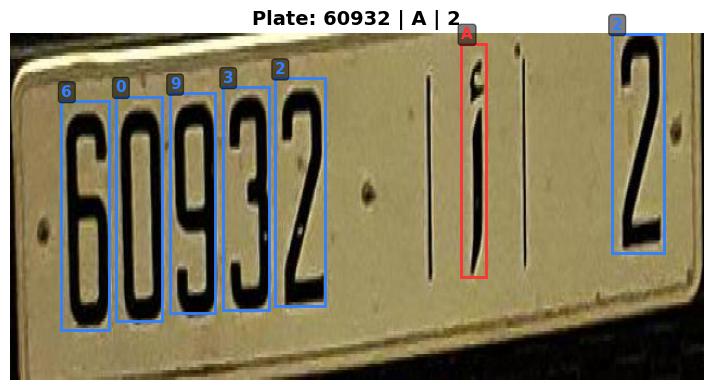

Detected plate: 60932 | A | 2


In [23]:
def parse_moroccan_plate(detections, class_names):
    """
    detections : list of (cls_id, x_center_pixel)
    Returns    : (part1_digits, letter, part2_digits) as strings
    """
    # Sort detections left → right
    sorted_dets = sorted(detections, key=lambda d: d[1])

    chars = [(class_names.get(c, '?'), c) for c, _ in sorted_dets]

    # Find the single letter (class 10-35)
    letter_idx = next(
        (i for i, (ch, c) in enumerate(chars) if 10 <= c <= 35), None
    )

    if letter_idx is None:
        return (''.join(ch for ch, _ in chars), '?', '')

    part1 = ''.join(ch for ch, _ in chars[:letter_idx])
    letter = chars[letter_idx][0]
    part2 = ''.join(ch for ch, _ in chars[letter_idx + 1:])
    return part1, letter, part2


def run_inference(image_path, model, class_names, conf=0.4):
    results = model.predict(image_path, conf=conf, verbose=False)[0]
    img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    detections = []
    for box in results.boxes:
        cls_id  = int(box.cls[0])
        x_ctr   = float(box.xywh[0][0])
        detections.append((cls_id, x_ctr))

    part1, letter, part2 = parse_moroccan_plate(detections, class_names)
    plate_str = f'{part1} | {letter} | {part2}'

    # Draw
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(img_rgb)
    ax.set_title(f'Plate: {plate_str}', fontsize=14, fontweight='bold')
    ax.axis('off')

    for box in results.boxes:
        cls_id = int(box.cls[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = class_color(cls_id)
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, class_names.get(cls_id, '?'),
                color=color, fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

    plt.tight_layout()
    plt.show()
    return plate_str


# ── Test on a single image ────────────────────────────────────────
TEST_IMAGE = '/teamspace/studios/this_studio/dataset/test/images/20201106_224430_contrast_jpg.rf.0834faf9039f1085d4c20fe85e98c3d0.jpg'   # ← change to your image
model_inf  = YOLO(best_weights)

plate = run_inference(TEST_IMAGE, model_inf, CLASS_NAMES)
print('Detected plate:', plate)

In [43]:
import yaml
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path


best_weights = "./weigths/best.pt"
DATA_YAML = "./dataset/data.yaml"
IMGSZ = 1280 

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg['names']          # dict  {0: '0', 1: '1', ..., 36: 'plate'}
NC          = cfg['nc']
print(f'Classes ({NC}):', CLASS_NAMES)
def class_color(cls_id):
    if cls_id <= 9:   return (0.2, 0.5, 1.0)   # blue  → digit
    if cls_id <= 35:  return (1.0, 0.2, 0.2)   # red   → letter
    return 
newnames = {
        0: '0',  1: '1',  2: '2',  3: '3',  4: '4',
        5: '5',  6: '6',  7: '7',  8: '8',  9: '9',
        10: 'أ', 11: 'ب', 12: 'د', 13: 'ه', 14: 'w',
        15: 'و'
    }    
CLASS_NAMES = newnames  

Classes (16): {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'a', 11: 'b', 12: 'd', 13: 'h', 14: 'w', 15: 'waw'}


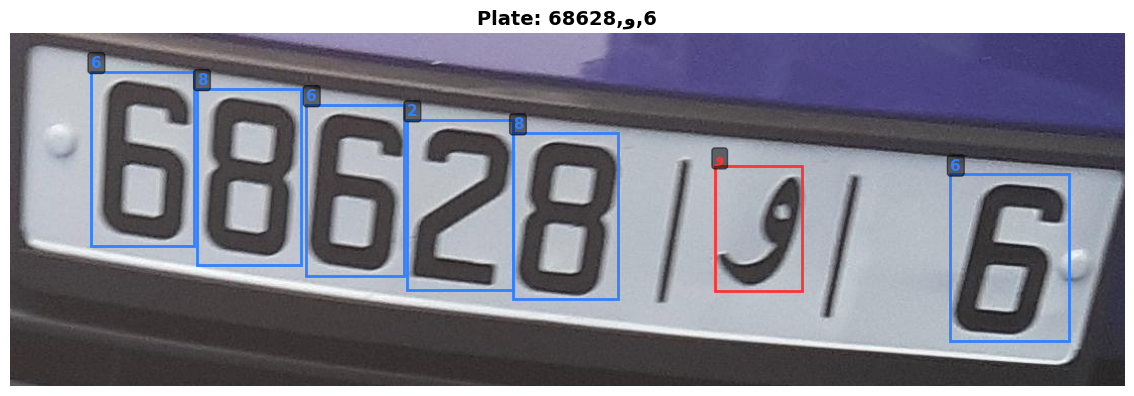

Detected plate: 68628,و,6


In [49]:
def parse_moroccan_plate(detections, class_names):
    # Sort detections left → right
    sorted_dets = sorted(detections, key=lambda d: d[1])

    chars = [(class_names.get(c, '?'), c) for c, _ in sorted_dets]

    # Find the single letter (class 10-35)
    letter_idx = next(
        (i for i, (ch, c) in enumerate(chars) if 10 <= c <= 35), None
    )

    if letter_idx is None:
        return (''.join(ch for ch, _ in chars), '', '')

    part1 = ''.join(ch for ch, _ in chars[:letter_idx])
    letter = chars[letter_idx][0]
    part2 = ''.join(ch for ch, _ in chars[letter_idx + 1:])
    return part1, letter, part2


def run_inference(image_path, model, class_names, conf=0.4):
    results = model.predict(image_path, conf=conf, verbose=False)[0]
    img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    detections = []
    for box in results.boxes:
        cls_id  = int(box.cls[0])
        x_ctr   = float(box.xywh[0][0])
        detections.append((cls_id, x_ctr))

    part1, letter, part2 = parse_moroccan_plate(detections, class_names)
    plate_str = f'{part1},{letter},{part2}'

    # Draw
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(img_rgb)
    ax.set_title(f'Plate: {plate_str}', fontsize=14, fontweight='bold')
    ax.axis('off')

    for box in results.boxes:
        cls_id = int(box.cls[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = class_color(cls_id)
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, class_names.get(cls_id, '?'),
                color=color, fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

    plt.tight_layout()
    plt.show()
    return plate_str


# ── Test on a single image ────────────────────────────────────────
TEST_IMAGE = './testdata/450_0_png.rf.e9203c096b77e09664c8071890706fb9.jpg' 
model_inf  = YOLO(best_weights)

plate = run_inference(TEST_IMAGE, model_inf, CLASS_NAMES)
print('Detected plate:', plate)

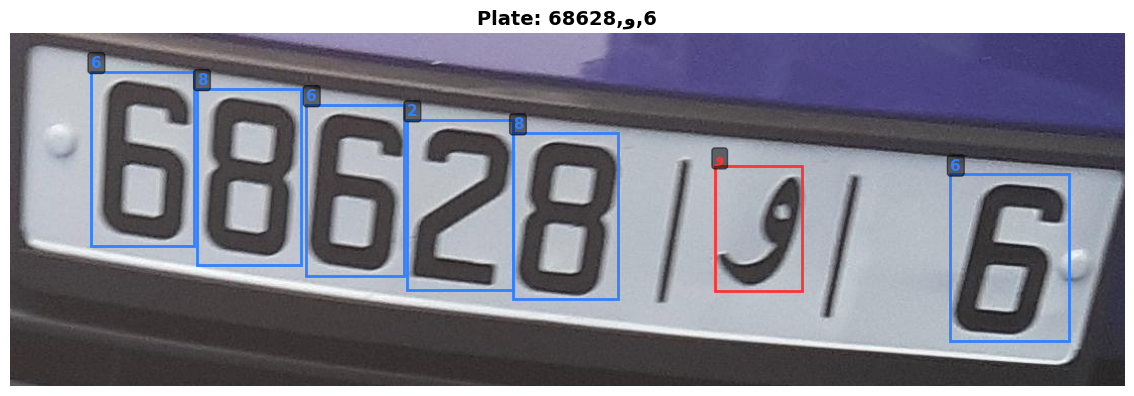

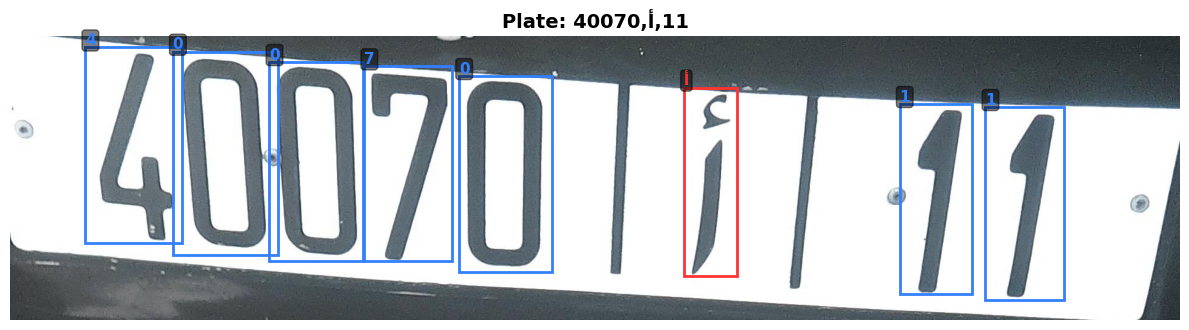

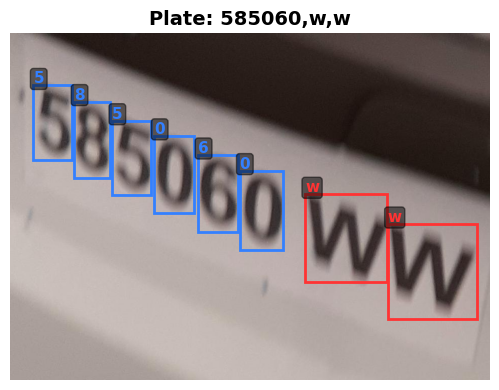

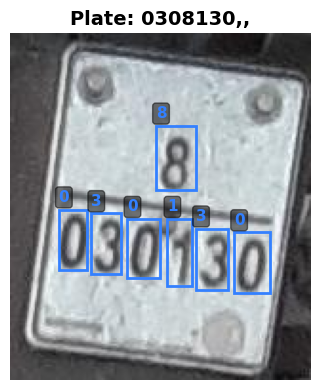

Results saved to results.csv


In [50]:
def test_folder(folder_path, model, class_names):
    # Create a DataFrame to store the results
    df = pd.DataFrame(columns=['imgname', 'preffix', 'letter', 'suffix'])

    # Iterate over each image in the folder
    for img_name in os.listdir(folder_path):
        if img_name.endswith('.jpg') or img_name.endswith('.png'):
            image_path = os.path.join(folder_path, img_name)
            plate_str = run_inference(image_path, model, class_names)
            
            # Extract preffix, letter, and suffix from the plate string
            parts = plate_str.split(',')
            df = pd.concat([df, pd.DataFrame({
                'image_name': [img_name],
                'left_digits': [parts[0]],
                'letter_ar': [parts[1]],
                'right_digits': [parts[2]]
            })], ignore_index=True)

    return df

# ── Test on a single image ────────────────────────────────────────
TEST_IMAGE = './testdata/36_jpg.rf.1e9f113aa6fc73c2b03643c5ef32fe34_aug1k_c3_62efc699.jpg' 
model_inf  = YOLO(best_weights)

# Specify the folder path
folder_path = './testdata'

# Run inference on the folder and save results to a CSV
df = test_folder(folder_path, model_inf, CLASS_NAMES)
df.to_csv('results.csv', index=False)

print('Results saved to results.csv')
